In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation as mad
import pandas as pd
plt.style.use('thesis')

In [45]:
wav = np.load('/home/vmehta/honours-project/code/data/wavelengths.npy')
f10 = '/avatar/vmehta/sfh_1000_10bins_20260406_125356/priors/softmaxprior'
pred10 = np.load(f'{f10}/snr1000_pred.npy')
true10 = np.load(f'{f10}/snr1000_true.npy')
res10 = pred10 - true10
spec10 = np.load('/home/vmehta/honours-project/code/data/sfh_tennormalbins_spectra.npy')

def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100)  # dealing with edges

norm_vals = [normalize(v) for v in spec10]

In [46]:
mean_fluxes = np.mean(spec10, axis=1)
total_fluxes = []
for i in range(len(true10)):
    total_flux = np.dot(true10[i], mean_fluxes)
    total_fluxes.append(total_flux)

flux_contributions = np.zeros((200, 10))
for i in range(200):
    for j in range(10):
        flux_contributions[i, j] = (true10[i, j] * mean_fluxes[j]) / total_fluxes[i]

mad5lower = np.median(res10) - 5*mad(res10)
mad5upper = np.median(res10) + 5*mad(res10)

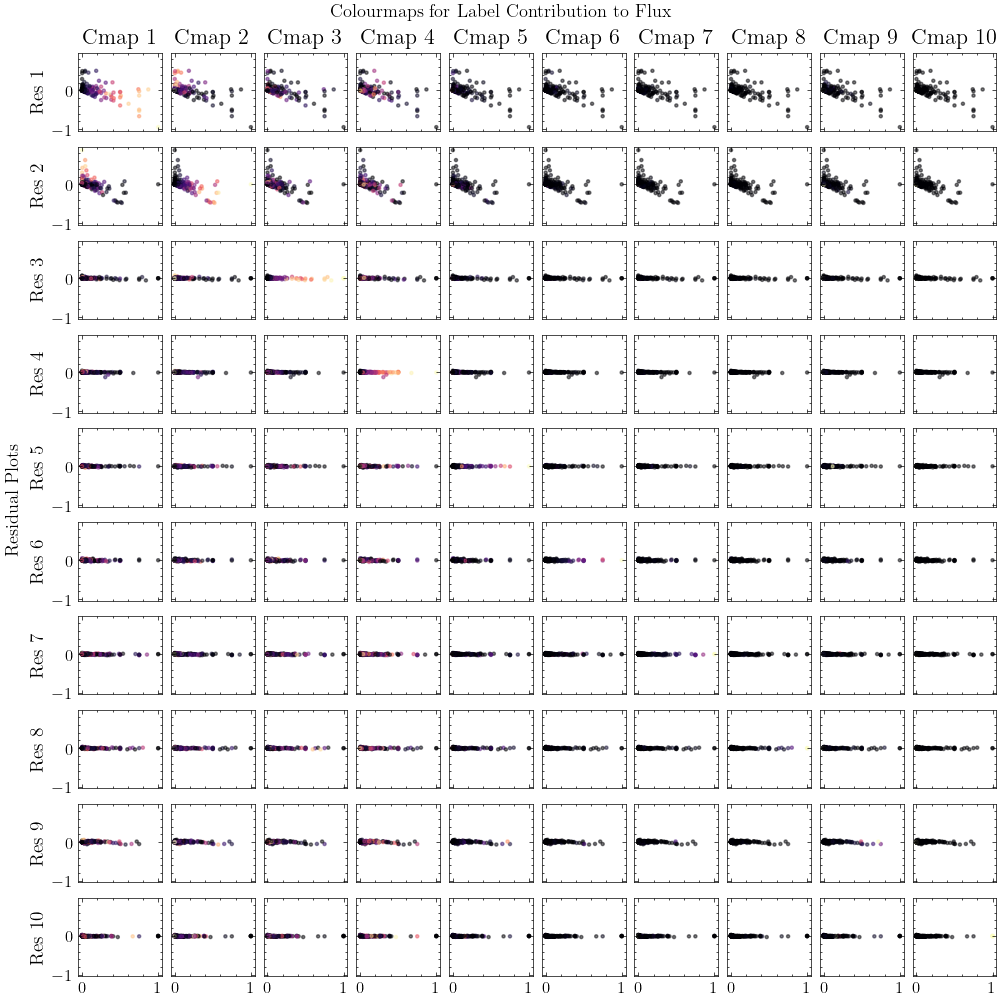

In [47]:
fig, ax = plt.subplots(10, 10, figsize=(10,10), sharex=True, sharey=True, constrained_layout=True)
for i in range(10):
    for j in range(10):
        ax[i,j].scatter(true10[:,i], res10[:,i], s=5, c=flux_contributions[:,j], cmap='magma', alpha=0.5)
        ax[i,0].set_ylabel(f'Res {i+1}')
        ax[0,j].set_title(f'Cmap {j+1}')

fig.supylabel('Residual Plots')
fig.suptitle('Colourmaps for Label Contribution to Flux')
plt.show()

In [48]:
df = pd.DataFrame(res10, columns=[f'Label {i+1}' for i in range(10)])

# Display one large residual table with out-of-band values highlighted
threshold = 0.02

def highlight_out_of_band(v):
    if pd.isna(v):
        return ''
    if v < -threshold or v > threshold:
        return 'background-color: #ffb3b3; font-weight: bold'
    return ''

styled_df = (
    df.style
    .format('{:.4f}')
    .map(highlight_out_of_band)
    .set_caption('Residual table (highlighted when value < -0.02 or > 0.02)')
)

# For wide tables, show all columns in notebook output
with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(styled_df)

,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10
0,-0.0165,-0.0142,0.0201,0.0101,0.0028,-0.0087,0.0063,-0.0064,0.0074,-0.0008
1,-0.0616,0.0632,-0.0049,-0.0037,0.0068,-0.0078,0.0003,-0.0002,0.0163,-0.0082
2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,-0.0093,0.0146,0.0013,-0.0089,-0.0078,0.0075,-0.0097,0.0086,0.0139,-0.0101
4,-0.0062,-0.0197,0.0306,-0.0001,-0.0119,-0.0008,0.0080,0.0005,-0.0015,0.0010
5,-0.0000,-0.0001,-0.0028,0.0004,0.0126,-0.0161,0.0106,-0.0083,0.0045,-0.0009
6,-0.0318,0.0117,0.0078,0.0123,0.0012,-0.0013,0.0088,-0.0077,-0.0103,0.0094
7,-0.0001,0.0502,-0.0492,-0.0078,-0.0111,0.0351,-0.0137,-0.0025,-0.0001,-0.0008
8,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0021,-0.0021,0.0000,0.0000
9,-0.3449,0.3025,0.0124,0.0094,-0.0208,0.0249,-0.0000,-0.0003,0.0209,-0.0041


In [14]:
# summary count of flagged values per label/column
flag_counts = ((df < -threshold) | (df > threshold)).sum()
display(flag_counts.to_frame(name='n_flagged_values'))

,n_flagged_values
Label 1,623
Label 2,617
Label 3,290
Label 4,263
Label 5,206
Label 6,247
Label 7,241
Label 8,214
Label 9,315
Label 10,232


7

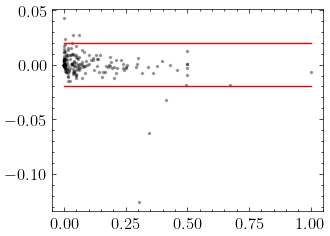

In [49]:
plt.plot(true10[:,3], res10[:,3], 'k.', markersize=3, alpha=0.3)
plt.plot([0,1], [-0.02, -0.02], 'r')
plt.plot([0,1], [0.02, 0.02], 'r')
fails = res10[:,3][(res10[:,3] < -0.02) | (res10[:,3] > 0.02)]
len(fails)

Text(0, 0.5, 'Number of spectra')

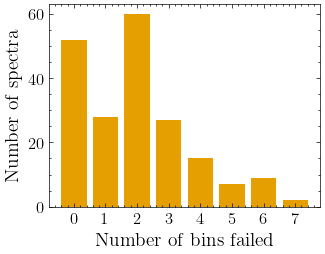

In [51]:
# histogram of number of bins failed in (from 0 to 10) for each spectrum
num_failed_bins = np.sum((res10 < -0.02) | (res10 > 0.02), axis=1)
plt.bar(range(8), np.bincount(num_failed_bins))
plt.xticks(range(8))
plt.xlabel('Number of bins failed')
plt.ylabel('Number of spectra')

In [18]:
# have a closer look at spectra that failed in all ten bins
failed_all_bins = np.where(num_failed_bins == 10)[0]
failed_all_bins

array([615, 621, 646, 706, 907, 951])

In [31]:
np.sum(pred10, axis=1)
# looks like the sum prior is failing???????

array([0.38165665, 0.56454281, 0.37456709, 1.02386317, 0.36664793,
       0.97896806, 1.00171234, 0.37677788, 1.00595176, 1.02649933,
       1.02653401, 1.03256499, 0.99839819, 0.37295831, 0.98589087,
       0.97689515, 0.98089359, 1.01492468, 0.42247113, 1.00650368,
       0.98875396, 1.02803991, 0.97853631, 1.00626673, 1.0142152 ,
       1.02649759, 0.37556318, 0.97478996, 1.00701947, 1.01469261,
       1.01207273, 0.38422662, 1.00989927, 1.02361191, 1.00530793,
       1.01064369, 0.99138664, 1.00985618, 0.9976288 , 0.47941278,
       0.42790317, 0.37961728, 0.96592613, 0.37150129, 1.01644579,
       0.99989773, 1.00776032, 0.99463584, 0.99206279, 1.04493985,
       1.02703521, 0.96974472, 0.99360352, 0.46159785, 0.40904333,
       1.00931487, 0.38786007, 1.08764567, 0.98442405, 1.02513925,
       0.90565172, 1.0004359 , 0.41524371, 0.9987216 , 0.61624018,
       0.3721123 , 0.99395462, 0.38248186, 0.45003005, 1.0208915 ,
       0.97676812, 0.98180782, 1.00113068, 0.98619629, 0.87295

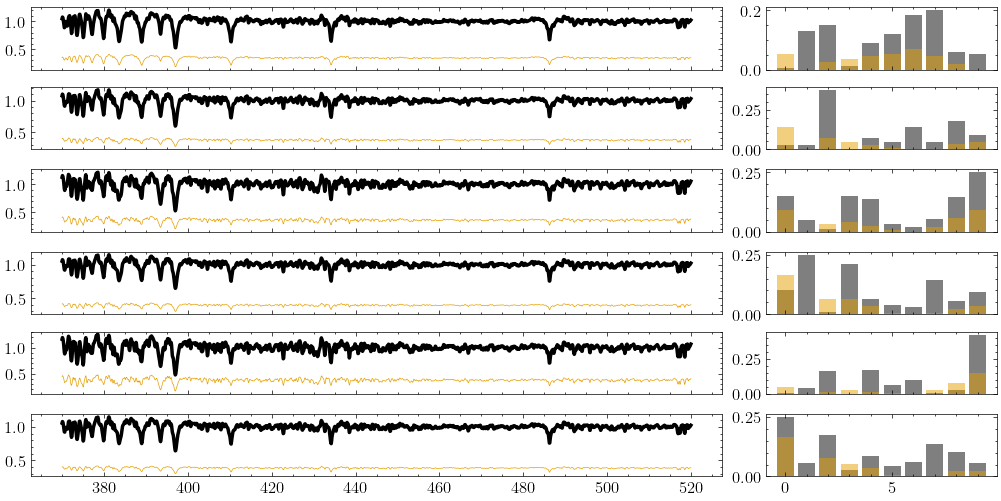

In [25]:
fig, ax = plt.subplots(6, 2, figsize=(10,5), sharex='col',gridspec_kw={'width_ratios': [3, 1]}, constrained_layout=True)

for i, n in enumerate(failed_all_bins):
    ax[i,0].plot(wav/10, true10[n] @ norm_vals, 'k', linewidth=2.5, label='Original')
    ax[i,0].plot(wav/10, pred10[n] @ norm_vals, 'C0', linewidth=0.5, label='Predicted')
    ax[i,1].bar(range(10), true10[n], color='k', alpha=0.5, label='True')
    ax[i,1].bar(range(10), pred10[n], color='C0', alpha=0.5, label='Predicted')

In [43]:
nf = np.load('/avatar/vmehta/sfh_1000_10bins_20260406_125356/priors/softmaxprior/snr1000_pred.npy')
sums = np.sum(nf, axis=1)